In [2]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import transforms
from torchvision import datasets
from transformers import AutoImageProcessor
from transformers import SwinForImageClassification
from transformers import TrainingArguments, Trainer

c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [5]:
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.targets):
        target_idx[int(label)].append(idx)

    indices = list(chain.from_iterable([target_idx[idx][:max_len] for idx in range(len(classes))]))
    return Subset(dataset, indices)

def model_init(classes, class_to_idx):
    return SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label = {idx: label for label, idx in class_to_idx.items()},
        label2id = class_to_idx,
        ignore_mismatched_sizes = True
    )

def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {'pixel_values': pixel_values, 'labels': labels}

def compute_metrics(eval_pred):
    metric = evaluate.load('f1')
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(predictions=predictions, references=labels, average='macro')
    return macro_f1

In [7]:
train_dataset = datasets.FashionMNIST(root= './datasets', download = True, train = True)
test_dataset = datasets.FashionMNIST(root= './datasets', download = True, train = False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(dataset = train_dataset, 
                                      classes = train_dataset.classes, 
                                      max_len = 1000)

subset_test_dataset = subset_sampler(dataset = test_dataset,
                                      classes = test_dataset.classes,
                                      max_len = 100)

In [8]:
image_processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size = (image_processor.size['height'],
                                 image_processor.size['width'])),
    transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
    transforms.Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
])

args = TrainingArguments(
    output_dir = './model/Swin-FashionMNIST',
    save_strategy = 'epoch',
    evaluation_strategy = 'epoch',
    learning_rate = 1e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.001,
    load_best_model_at_end = True,
    metric_for_best_model = 'f1',
    logging_dir = 'logs',
    logging_steps = 125,
    remove_unused_columns = False,
    seed = 42)

trainer = Trainer(model_init = lambda x: model_init(classes, class_to_idx),
                  args = args, train_dataset = subset_train_dataset,
                  eval_dataset = subset_test_dataset,
                  data_collator = lambda x: collator(x, transform),
                  compute_metrics = compute_metrics,
                  tokenizer = image_processor)

trainer.train()

c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KDS23\.cache\huggingface\hub\models--microsoft--swin-tiny-patch4-window7-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Wi

{'loss': 1.1987, 'learning_rate': 9.333333333333334e-06, 'epoch': 0.2}


 13%|█▎        | 251/1875 [00:41<04:42,  5.75it/s]

{'loss': 0.5217, 'learning_rate': 8.666666666666668e-06, 'epoch': 0.4}


 20%|██        | 376/1875 [01:02<04:07,  6.05it/s]

...

                                                   
100%|██████████| 1875/1875 [05:27<00:00,  6.30it/s]

{'eval_loss': 0.23793628811836243, 'eval_f1': 0.9190349225427307, 'eval_runtime': 6.334, 'eval_samples_per_second': 157.878, 'eval_steps_per_second': 9.946, 'epoch': 3.0}


100%|██████████| 1875/1875 [05:28<00:00,  5.71it/s]

{'train_runtime': 328.1423, 'train_samples_per_second': 91.424, 'train_steps_per_second': 5.714, 'train_loss': 0.3742840830485026, 'epoch': 3.0}


TrainOutput(global_step=1875, training_loss=0.3742840830485026, metrics={'train_runtime': 328.1423, 'train_samples_per_second': 91.424, 'train_steps_per_second': 5.714, 'train_loss': 0.3742840830485026, 'epoch': 3.0})

100%|██████████| 63/63 [00:06<00:00, 10.18it/s]


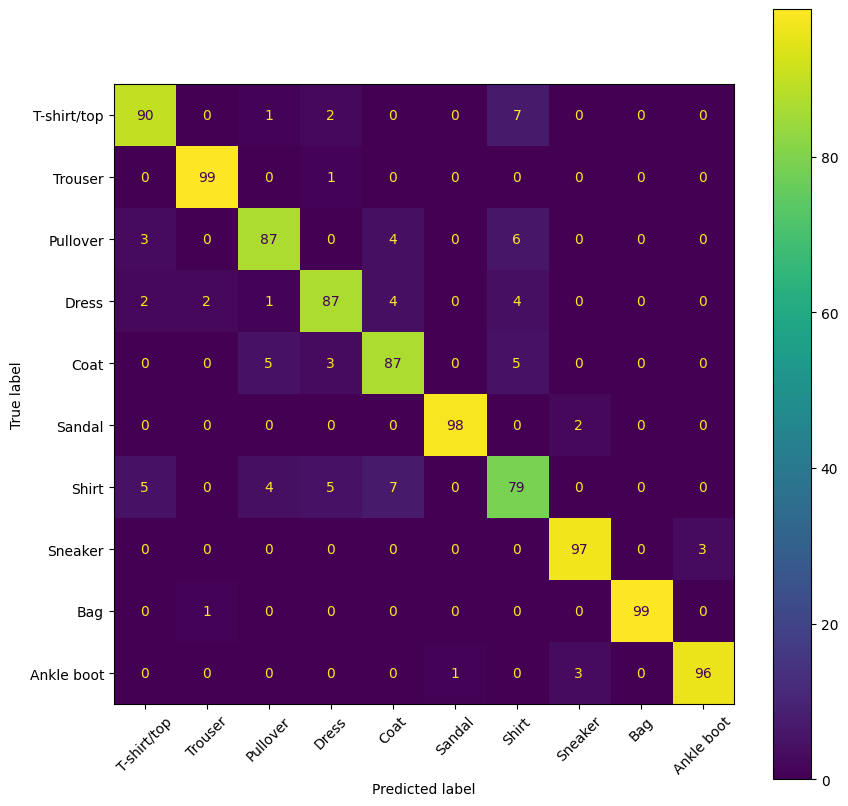

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

outputs = trainer.predict(subset_test_dataset)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)
labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = labels)

_, ax = plt.subplots(figsize = (10,10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()
